# Superstore Sales Data Analysis

## Objective
Evaluate and improve overall profitability by analyzing performance across categories, regions, segments, and time, and assess the impact of discount strategy.

---

In [18]:
#Import Libraries

import pandas as pd
import matplotlib.pyplot as plt

In [19]:
#Load Dataset
df = pd.read_csv("Superstore.csv", encoding='ISO-8859-1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [20]:
#Structural Overview

df.shape
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [21]:
#Data Cleaning

# Convert date columns
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

# Check duplicates
df.duplicated().sum()

np.int64(0)

In [22]:
#Feature Engineering

# Create Profit Margin
df["Profit Margin"] = df["Profit"] / df["Sales"]

# Extract time features
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Quarter"] = df["Order Date"].dt.quarter

# Create Loss Flag
df["Loss Flag"] = df["Profit"] < 0

In [23]:
# Overall Performance

total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
overall_margin = total_profit / total_sales

total_sales, total_profit, overall_margin

(np.float64(2297200.8603),
 np.float64(286397.0217),
 np.float64(0.12467217240315605))

In [24]:
#Yearly Performance

yearly = df.groupby("Year")[["Sales", "Profit"]].sum()
yearly["Margin"] = yearly["Profit"] / yearly["Sales"]
yearly

,Sales,Profit,Margin
Year,,,
2014,484247.4981,49543.9741,0.102311
2015,470532.5090,61618.6037,0.130955
2016,609205.5980,81795.1743,0.134265
2017,733215.2552,93439.2696,0.127438


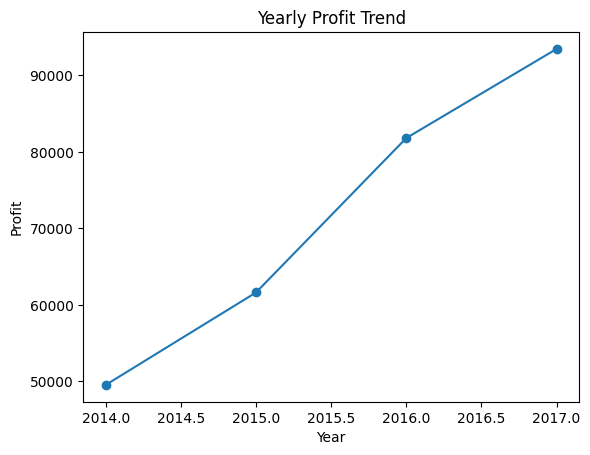

In [25]:
#Yearly Profit Trend

yearly["Profit"].plot(kind="line", marker="o")
plt.title("Yearly Profit Trend")
plt.ylabel("Profit")
plt.show()

In [26]:
#Category Analysis

df.groupby("Category")[["Profit"]].sum()
df.groupby("Category")[["Profit Margin"]].mean()
df.groupby("Category")["Loss Flag"].sum()

Category
Furniture          714
Office Supplies    886
Technology         271
Name: Loss Flag, dtype: int64

In [27]:
#Region Analysis

df.groupby("Region")[["Profit"]].sum()
df.groupby("Region")[["Profit Margin"]].mean()
df.groupby("Region")["Loss Flag"].sum()

Region
Central    741
East       553
South      259
West       318
Name: Loss Flag, dtype: int64

In [28]:
#Segment Analysis

df.groupby("Segment")[["Profit"]].sum()
df.groupby("Segment")[["Profit Margin"]].mean()
df.groupby("Segment")["Loss Flag"].sum()

Segment
Consumer       1003
Corporate       556
Home Office     312
Name: Loss Flag, dtype: int64

In [29]:
#Discount Impact Analysis

df[["Discount", "Profit Margin"]].corr()

,Discount,Profit Margin
Discount,1.000000,-0.864452
Profit Margin,-0.864452,1.000000


In [30]:
df["Discount Bucket"] = pd.cut(df["Discount"], bins=[0,0.2,0.4,0.6,0.8,1])
df.groupby("Discount Bucket")["Profit Margin"].mean()

C:\Users\VINOD\AppData\Local\Temp\ipykernel_22868\252737955.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Discount Bucket")["Profit Margin"].mean()


Discount Bucket
(0.0, 0.2]    0.174368
(0.2, 0.4]   -0.166855
(0.4, 0.6]   -0.634140
(0.6, 0.8]   -1.225209
(0.8, 1.0]         NaN
Name: Profit Margin, dtype: float64

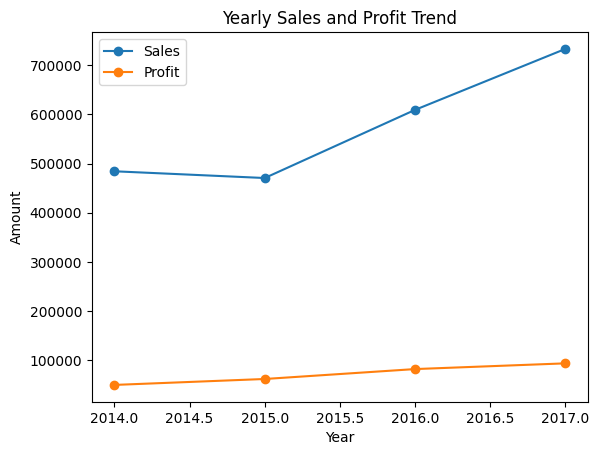

In [31]:
# Visual Analysis
#Sales vs Profit Trend

yearly[["Sales", "Profit"]].plot(marker="o")
plt.title("Yearly Sales and Profit Trend")
plt.ylabel("Amount")
plt.show()


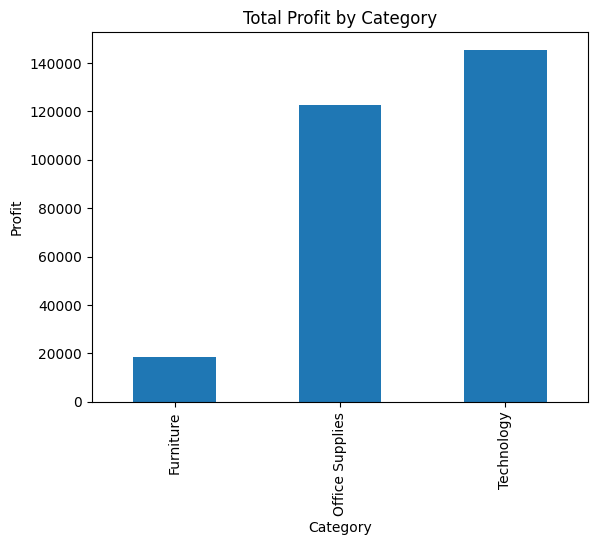

In [32]:
#Profit by Category

df.groupby("Category")["Profit"].sum().plot(kind="bar")
plt.title("Total Profit by Category")
plt.ylabel("Profit")
plt.show()

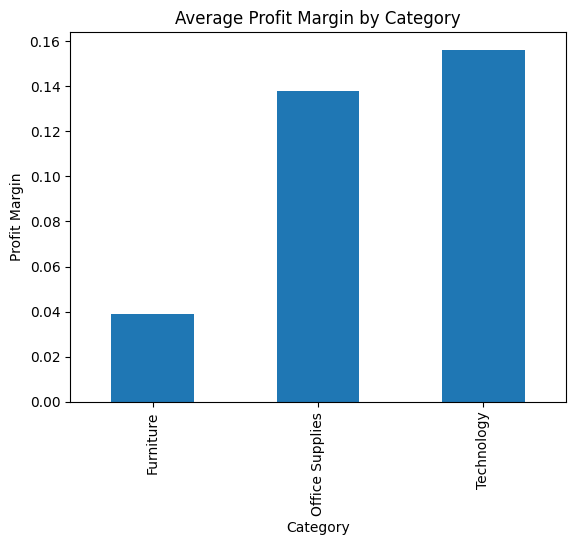

In [33]:
#Profit Margin by Category

df.groupby("Category")["Profit Margin"].mean().plot(kind="bar")
plt.title("Average Profit Margin by Category")
plt.ylabel("Profit Margin")
plt.show()

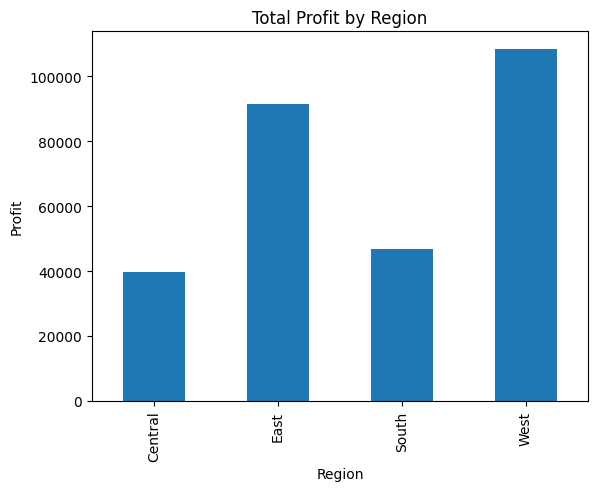

In [34]:
#Profit by Region

df.groupby("Region")["Profit"].sum().plot(kind="bar")
plt.title("Total Profit by Region")
plt.ylabel("Profit")
plt.show()

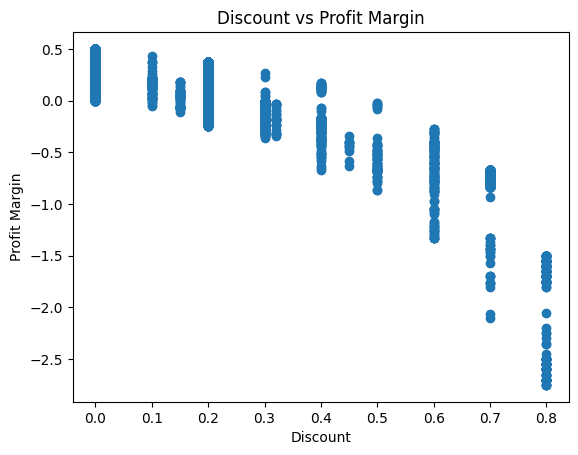

In [35]:
#Discount vs Profit Margin

plt.scatter(df["Discount"], df["Profit Margin"])
plt.title("Discount vs Profit Margin")
plt.xlabel("Discount")
plt.ylabel("Profit Margin")
plt.show()

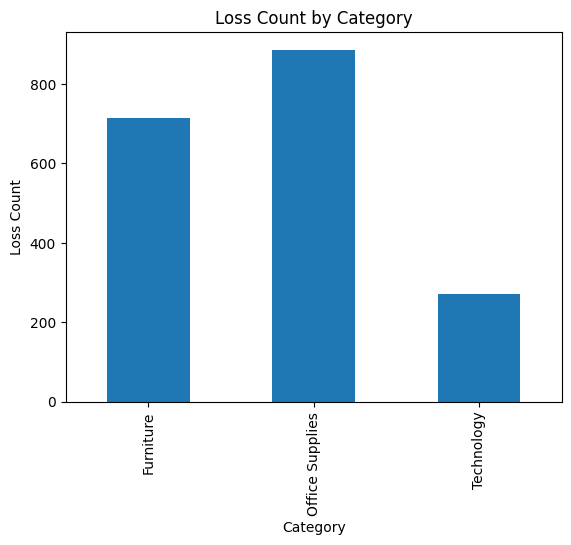

In [36]:
#Loss Distribution

df.groupby("Category")["Loss Flag"].sum().plot(kind="bar")
plt.title("Loss Count by Category")
plt.ylabel("Loss Count")
plt.show()

## Key Insights

- The company maintains a positive overall profit margin (~12%) with consistent growth over time.
- Technology category and West region are the strongest contributors in both scale and efficiency.
- Furniture category and Central region show structural profitability weaknesses.
- Higher discount levels negatively impact profit margin.
- Consumer segment drives scale but operates at relatively lower efficiency.

---

## Recommendations

- Review pricing and cost structure in Central region.
- Optimize discount strategy to protect margins.
- Improve operational efficiency in Furniture category.
- Explore scaling high-efficiency segments such as Home Office.